In [1]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
import cv2
from PIL import Image
import torchvision.transforms as T
from google.colab.patches import cv2_imshow


In [2]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 133MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [3]:
transform = T.Compose([T.ToTensor()])

In [5]:
img_path = "/content/traffic.jpeg"
img = Image.open(img_path)
img_tensor = transform(img).unsqueeze(0)

In [8]:
with torch.no_grad():
 predictions = model(img_tensor)


In [9]:
pred_boxes = predictions[0]['boxes']
pred_scores = predictions[0]['scores']
pred_labels = predictions[0]['labels']


In [11]:
img_cv = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
car_count = 0
for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
    if score > 0.6:
        # Get the label name using the index
        label_name = weights.meta['categories'][label]
        if label_name == 'car':
            car_count += 1
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
            text = f"{label_name}: {score:.2f}"
            cv2.putText(img_cv, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

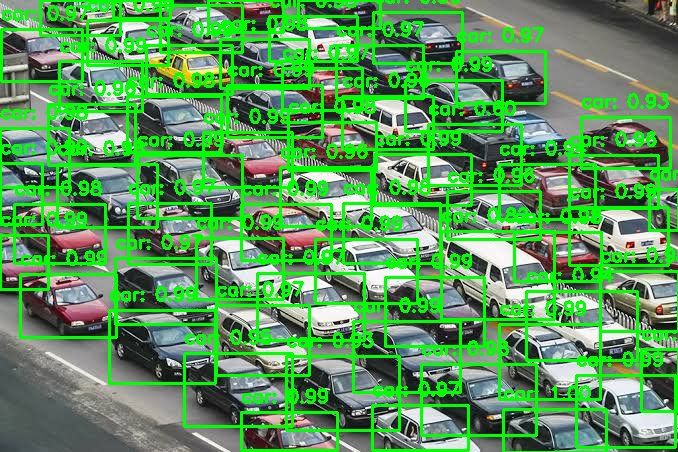

Total number of cars detected: 62


In [12]:
cv2_imshow(cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR))
print(f"Total number of cars detected: {car_count}")